In [7]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [3]:
df

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [13]:
df.sample()['clean_comment'].values

array(['yeddy last line before ending his latest press conference get touch with amit shah sure '],
      dtype=object)

In [15]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [18]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [19]:
df[df['clean_comment'].isna()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df.isnull().sum()

clean_comment    0
category         0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(350)

In [27]:
df[df.duplicated()].tail()

,clean_comment,category
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1
37234,this part series minute videos focusing each d...,1


In [28]:
df.drop_duplicates(inplace=True)

In [31]:
df[df['clean_comment'].str.strip() ==""]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [33]:
df=df[~(df['clean_comment'].str.strip() =="")]

In [34]:
df[df['clean_comment'].str.strip() ==""]

,clean_comment,category


In [35]:
df['clean_comment']=df['clean_comment'].str.lower()

C:\Users\shans\AppData\Local\Temp\ipykernel_13992\980075517.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment']=df['clean_comment'].str.lower()


In [36]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [40]:
df[df['clean_comment'].apply(lambda x:x.startswith(' ') or x.endswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [41]:
df['clean_comment']=df['clean_comment'].str.strip()


C:\Users\shans\AppData\Local\Temp\ipykernel_13992\1930201364.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment']=df['clean_comment'].str.strip()


In [44]:
comments_with_line=df[df['clean_comment'].str.contains('\n')]
comments_with_line.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [45]:
df['clean_comment']=df['clean_comment'].str.replace('\n',' ',regex=True)

C:\Users\shans\AppData\Local\Temp\ipykernel_13992\3118914311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_comment']=df['clean_comment'].str.replace('\n',' ',regex=True)


In [46]:
comments_with_line=df[df['clean_comment'].str.contains('\n')]
comments_with_line.head()

,clean_comment,category


<Axes: xlabel='category', ylabel='count'>

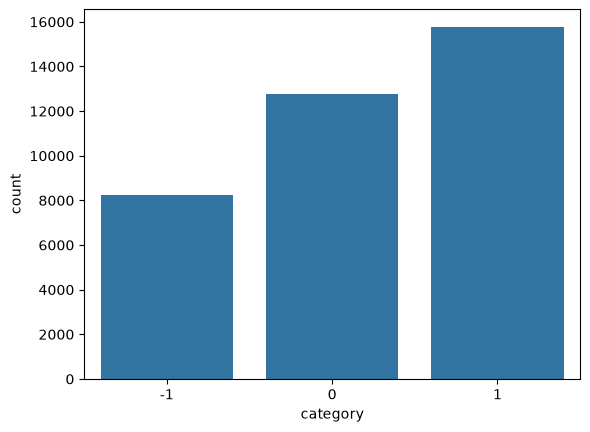

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df,x="category")

In [52]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [55]:
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))
df['word_count']

C:\Users\shans\AppData\Local\Temp\ipykernel_13992\2169027016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))


0         39
1        196
2         86
3         29
4        112
        ... 
37244      1
37245     19
37246      6
37247      2
37248      6
Name: word_count, Length: 36793, dtype: int64

In [57]:
df['word_count'].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

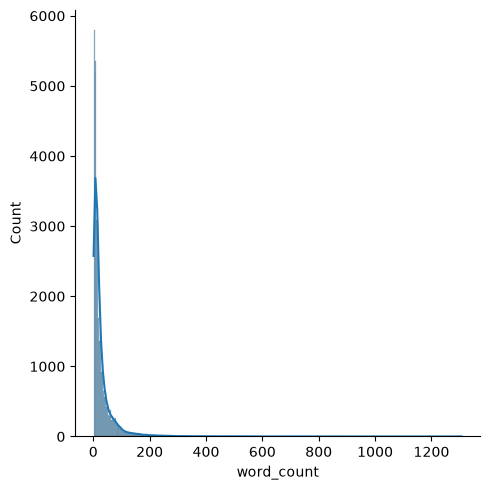

In [59]:
sns.displot(data=df, x='word_count', kde=True)

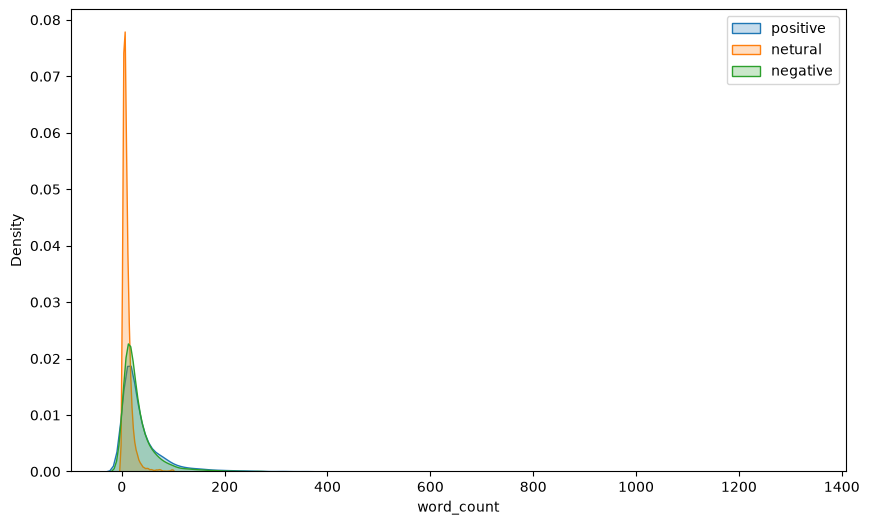

In [61]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df['category']==1]['word_count'],label='positive',fill=True)

sns.kdeplot(df[df['category']==0]['word_count'],label='netural',fill=True)
sns.kdeplot(df[df['category']==-1]['word_count'],label='negative',fill=True)




plt.legend()

<Axes: ylabel='word_count'>

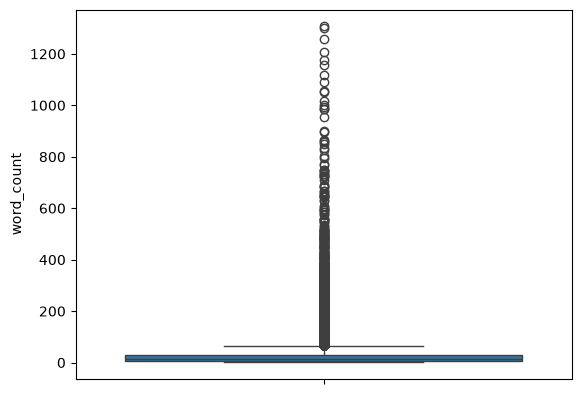

In [62]:
sns.boxplot(df['word_count'])

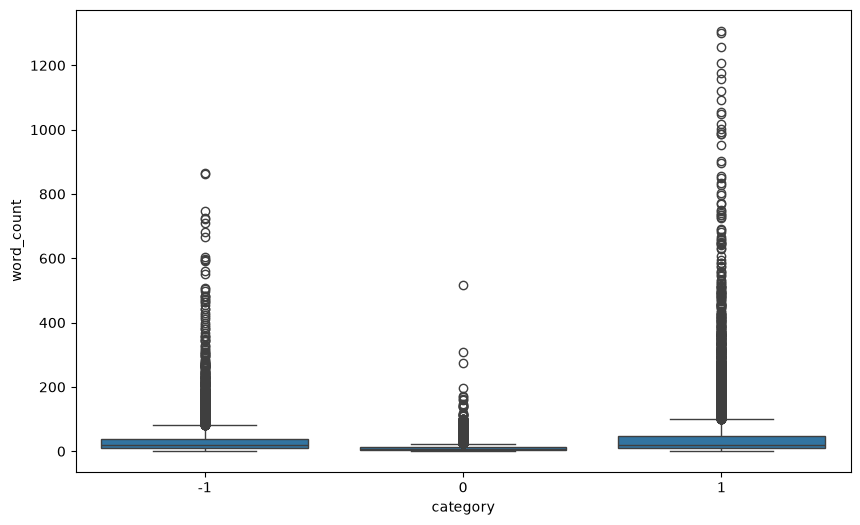

In [63]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='category',y='word_count')
plt.show()

In [66]:
pip install nltk

  Using cached regex-2026.7.19-cp311-cp311-win_amd64.whl.metadata (41 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.5 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.5 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.4 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.4 MB/s  0:00:01
Using cached regex-2026.7.19-cp311-cp311-win_amd64.whl (277 kB)

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   -------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopword')

set_stopword=set(stopwords.words('english'))

df['num_stop_word']=df['clean_comment'].apply(lambda x:len([ word for word in x.split() if word in set_stopword]))

[nltk_data] Error loading stopword: Package 'stopword' not found in
[nltk_data]     index
C:\Users\shans\AppData\Local\Temp\ipykernel_13992\258474656.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_stop_word']=df['clean_comment'].apply(lambda x:len([ word for word in x.split() if word in set_stopword]))


In [74]:
df.sample(5)

,clean_comment,category,word_count,num_stop_word
15318,even congress did the same when came the cbi o...,-1,57,24
22327,good see him take ques unlike his counterpart,1,8,2
16698,the end video akshay kumar says mallika aap be...,1,62,13
33221,micro targetting real thing,1,4,0
10000,team 5ppr start allen robinson thomas rawls de...,0,13,0
